# 📊 SDIC Libraries - Demonstração Completa

Este notebook demonstra todas as funcionalidades principais da biblioteca SDIC para acesso a dados de emprego brasileiros.

## 🚀 Antes de Começar

### Métodos de Instalação:

**Opção 1 - Biblioteca Instalada:**
```bash
cd python
pip install -e .
```

**Opção 2 - Via GitHub:**
```bash
pip install git+https://github.com/<SEU_USUARIO>/sdic_libraries.git#subdirectory=python
```

**Opção 3 - Automática (use células abaixo se houver erro)**

---

## 🎯 Conteúdo
1. **Configuração Inicial** - Importações e setup
2. **Dados Nacionais** - Exemplos com agrupamentos por nível CNAE
3. **Dados Estaduais** - Exemplos regionais com agrupamentos
4. **Dados Municipais** - Exemplos locais com agrupamentos
5. **Função criar_indice** - Análise temporal com índices
6. **Exemplos Práticos** - Casos de uso reais

---

## ⚠️ Solução de Problemas

Se encontrar **ModuleNotFoundError**:
1. Execute a célula de "Verificação de Instalação" abaixo
2. Reinicie o kernel após instalação  
3. Execute novamente as importações

**Versão da biblioteca**: 0.3.2

## 1. 🔧 Configuração Inicial

In [1]:

# 📦 Configuração inicial robusta e detecção de dependências

import sys
import importlib.util
import os
import subprocess

# Configurar path para importações locais
notebook_dir = os.path.dirname(os.path.abspath(__name__ if __name__ != '__main__' else "demo.ipynb"))
parent_dir = os.path.dirname(notebook_dir)

try:
    # Primeiro, tentar adicionar o diretório de desenvolvimento
    parent_python_dir = os.path.join(parent_dir, "python")
    if parent_python_dir not in sys.path and os.path.exists(parent_python_dir):
        sys.path.insert(0, parent_python_dir)
        print(f"✅ Adicionado ao path: {parent_python_dir}")
    
    # Tentar importar a biblioteca principal
    from sdic_libraries.dados.emprego import (
        get_saldo_emprego_nacional_mensal,
        get_saldo_emprego_nacional_anual, 
        get_saldo_emprego_nacional_mensal_agrupado,
        get_saldo_emprego_estadual_mensal,
        get_saldo_emprego_estadual_anual,
        get_saldo_emprego_estadual_mensal_agrupado,
        get_saldo_emprego_municipal_mensal,
        get_saldo_emprego_municipal_anual,
        get_saldo_emprego_municipal_mensal_agrupado,
        get_estoque_emprego_nacional,
        get_estoque_emprego_estadual,
        get_estoque_emprego_estimado_nacional_anual,
        get_estoque_emprego_estimado_estadual_anual,
        get_estoque_emprego_estimado_nacional_anual_agrupado,
        get_estoque_emprego_estimado_estadual_anual_agrupado,
    )
    
    from sdic_libraries.dados.emprego import Emprego
    from sdic_libraries.utils.transformacoes import criar_indice
    
    library_loaded = True
    print("✅ Biblioteca sdic_libraries carregada com sucesso!")
    
except ImportError as e:
    print(f"⚠️ Erro ao carregar biblioteca local: {e}")
    
    # Lista de dependências necessárias
    required_packages = ['pandas', 'requests']
    missing_deps = []
    
    # Verificar dependências básicas
    for package in required_packages:
        spec = importlib.util.find_spec(package)
        if spec is None:
            missing_deps.append(package)
    
    if missing_deps:
        print(f"📦 Instalando dependências faltantes: {missing_deps}")
        for package in missing_deps:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print("✅ Dependências instaladas!")
    
    # Importar dependências básicas
    import pandas as pd
    import json
    from datetime import datetime, timedelta
    try:
        from IPython.display import display
    except ImportError:
        def display(obj):
            print(obj)
    
    library_loaded = False
    error_messages = []
    
    # Definir função mock realística
    def mock_function(*args, **kwargs):
        print(f"⚠️ Chamada mock para função com args: {args[:2]}...") 
        return pd.DataFrame({
            'competencia': ['2024-01', '2024-02', '2024-03'],
            'saldo_emprego': [10000, 11000, 12000],
            'saldo_reajustado': [5000, 5500, 6000],
            'saldo_sem_reajuste': [4000, 4200, 4300]
        })
    
    def mock_estoque(*args, **kwargs):
        print(f"⚠️ Chamada mock para função de estoque com args: {args[:2]}...")
        return pd.DataFrame({
            'ano': [2022, 2023, 2024],
            'estoque_trabalhadores': [100000, 110000, 120000],
        })
    
    def mock_estimado(*args, **kwargs):
        print(f"⚠️ Chamada mock para função de estoque estimado com args: {args[:2]}...")
        return pd.DataFrame({
            'ano': [2022, 2023, 2024, 2025],
            'estoque_trabalhadores': [100000, 110000, 120000, 125000],
            'origem': ['Real', 'Real', 'Real', 'Estimação'],
        })
    
    # Atribuir funções mock
    globals().update({
        'get_saldo_emprego_nacional_mensal': mock_function,
        'get_saldo_emprego_nacional_anual': mock_function,
        'get_saldo_emprego_nacional_mensal_agrupado': mock_function,
        'get_saldo_emprego_estadual_mensal': mock_function,
        'get_saldo_emprego_estadual_anual': mock_function,
        'get_saldo_emprego_estadual_mensal_agrupado': mock_function,
        'get_saldo_emprego_municipal_mensal': mock_function,
        'get_saldo_emprego_municipal_anual': mock_function,
        'get_saldo_emprego_municipal_mensal_agrupado': mock_function,
        'get_estoque_emprego_nacional': mock_estoque,
        'get_estoque_emprego_estadual': mock_estoque,
        'get_estoque_emprego_estimado_nacional_anual': mock_estimado,
        'get_estoque_emprego_estimado_estadual_anual': mock_estimado,
        'get_estoque_emprego_estimado_nacional_anual_agrupado': mock_estimado,
        'get_estoque_emprego_estimado_estadual_anual_agrupado': mock_estimado,
    })
    
    class MockEmprego:
        def __init__(self):
            print("⚠️ Classe Emprego mock - biblioteca não instalada")
    
    def criar_indice(df, ano_base, coluna_data, colunas_valores):
        print("⚠️ Função criar_indice mock - biblioteca não instalada")
        return df
    
    Emprego = MockEmprego
    print("⚠️ Funções mock ativadas - instale a biblioteca para funcionalidade completa")
    
print("\n✅ Configuração inicial completa!")
print("📌 Status da biblioteca:", "✅ CARREGADA" if library_loaded else "❌ MOCK MODE")


✅ Biblioteca sdic_libraries carregada com sucesso!

✅ Configuração inicial completa!
📌 Status da biblioteca: ✅ CARREGADA


### 📋 Verificação de Instalação

Se você encontrou erros de importação, execute a célula abaixo para instalar a biblioteca automaticamente:

In [2]:
# 🔧 Instalação automática da biblioteca (execute apenas se houver erro de importação)
import subprocess
import sys
import os

def install_dependencies():
    """Instala as dependências necessárias"""
    try:
        # Lista de dependências essenciais
        dependencies = [
            "requests>=2.28.0",
            "pandas>=1.5.0", 
            "numpy>=1.24.0",
            "python-dotenv>=1.0.0",
            "matplotlib>=3.5.0",
            "seaborn>=0.11.0"
        ]
        
        print("📦 Instalando dependências...")
        for dep in dependencies:
            result = subprocess.run([
                sys.executable, "-m", "pip", "install", dep
            ], capture_output=True, text=True)
            
            if result.returncode == 0:
                print(f"✅ {dep.split('>=')[0]} instalado")
            else:
                print(f"⚠️ {dep.split('>=')[0]} - possível problema")
        
        return True
    except Exception as e:
        print(f"❌ Erro na instalação de dependências: {e}")
        return False

def install_sdic_library():
    """Instala a biblioteca SDIC automaticamente"""
    try:
        # Navegar para a pasta python e instalar
        notebook_dir = os.path.dirname(os.path.abspath('__file__'))
        python_dir = os.path.join(os.path.dirname(notebook_dir))
        
        print(f"📁 Instalando de: {python_dir}")
        
        # Primeiro instalar dependências
        requirements_file = os.path.join(python_dir, "requirements.txt")
        if os.path.exists(requirements_file):
            result = subprocess.run([
                sys.executable, "-m", "pip", "install", "-r", requirements_file
            ], capture_output=True, text=True)
            
            if result.returncode == 0:
                print("✅ Dependências instaladas!")
            else:
                print("⚠️ Problema com dependências, tentando instalação básica...")
                install_dependencies()
        
        # Executar pip install -e .
        result = subprocess.run([
            sys.executable, "-m", "pip", "install", "-e", python_dir
        ], capture_output=True, text=True, cwd=python_dir)
        
        if result.returncode == 0:
            print("✅ Biblioteca SDIC instalada com sucesso!")
            print("🔄 Reinicie o kernel e execute novamente as células de importação")
            return True
        else:
            print("❌ Erro na instalação:", result.stderr)
            return False
            
    except Exception as e:
        print(f"❌ Erro durante instalação: {e}")
        return False

def check_installation():
    """Verifica se a biblioteca está instalada corretamente"""
    try:
        import sdic_libraries
        print("✅ Biblioteca SDIC está instalada!")
        print(f"📦 Versão: {sdic_libraries.__version__}")
        print(f"📧 Contato: {sdic_libraries.__email__}")
        return True
    except ImportError:
        print("❌ Biblioteca SDIC não está instalada")
        return False

def check_dependencies():
    """Verifica dependências essenciais"""
    deps = {
        'pandas': 'pandas>=1.5.0',
        'numpy': 'numpy>=1.24.0', 
        'requests': 'requests>=2.28.0',
        'matplotlib': 'matplotlib>=3.5.0',
        'seaborn': 'seaborn>=0.11.0'
    }
    
    missing = []
    for module, requirement in deps.items():
        try:
            __import__(module)
            print(f"✅ {module}")
        except ImportError:
            print(f"❌ {module} - não encontrado")
            missing.append(requirement)
    
    return missing

# Verificar instalação
print("🔍 Verificando instalação da biblioteca SDIC...")
print("\n📋 Verificando dependências:")
missing_deps = check_dependencies()

if missing_deps:
    print(f"\n⚠️ Dependências faltando: {len(missing_deps)}")
    print("🔧 Instalando dependências...")
    install_dependencies()

print("\n🔍 Verificando biblioteca SDIC:")
if not check_installation():
    print("\n🔧 Instalando biblioteca automaticamente...")
    if install_sdic_library():
        print("\n🎯 Próximos passos:")
        print("1. Kernel > Restart Kernel")
        print("2. Execute novamente as células de importação")
    else:
        print("\n📝 Instalação manual:")
        print("1. Abra um terminal")
        print("2. cd python") 
        print("3. pip install -r requirements.txt")
        print("4. pip install -e .")
else:
    print("🚀 Pronto para usar a biblioteca!")
    
print(f"\n💻 Python: {sys.version.split()[0]}")
print(f"📁 Diretório: {os.getcwd()}")

🔍 Verificando instalação da biblioteca SDIC...

📋 Verificando dependências:
✅ pandas
✅ numpy
✅ requests
✅ matplotlib
✅ seaborn

🔍 Verificando biblioteca SDIC:
✅ Biblioteca SDIC está instalada!
📦 Versão: 0.3.2
📧 Contato: sdic.dados@mdic.gov.br
🚀 Pronto para usar a biblioteca!

💻 Python: 3.14.2
📁 Diretório: ./python/examples


## 2. 📈 Dados Nacionais - Exemplos com Agrupamentos

### 2.1 Saldo Nacional por Divisão CNAE (Nível 2)

In [21]:
# Exemplo 1: Dados nacionais mensais - Indústria Alimentícia (Divisão 10)
print("🍖 Dados Nacionais - Indústria Alimentícia (Divisão 10)")

try:
    dados_alimentos = get_saldo_emprego_nacional_mensal(
        nivel_cnae='divisao',
        codigo_cnae='10',
        data_minima='2023-01-01'
    )

    print(f"📊 Registros obtidos: {len(dados_alimentos)}")
    print("\n📅 Últimos 3 meses:")
    display(dados_alimentos.tail(3))

    # Estatísticas básicas
    print(f"\n📈 Saldo médio mensal: {dados_alimentos['saldo_reajustado'].mean():.0f}")
    print(f"📊 Saldo Reajustado médio: {dados_alimentos['saldo_reajustado'].mean():.0f}")
    print(f"📉 Saldo Sem Reajuste médio: {dados_alimentos['saldo_sem_reajuste'].mean():.0f}")
    
except Exception as e:
    print(f"❌ Erro ao obter dados: {e}")
    print("💡 Verifique se a biblioteca está instalada e se há conexão com a internet")
    # Criar dados de exemplo para demonstração
    dados_alimentos = pd.DataFrame({
        'competencia': ['2023-01', '2023-02', '2023-03'],
        'saldo_emprego': [50000, 51000, 52000],
        'admissoes': [25000, 26000, 27000],
        'desligamentos': [20000, 21000, 22000]
    })
    print("\n📝 Usando dados de exemplo para demonstração:")
    display(dados_alimentos)

🍖 Dados Nacionais - Indústria Alimentícia (Divisão 10)
📊 Registros obtidos: 39

📅 Últimos 3 meses:


,mes_referencia,divisao_cnae_cod,divisao_cnae_desc,saldo_reajustado,saldo_sem_reajuste
36,2023-03-01,10,Fabricação De Produtos Alimentícios,4833.0,4698.0
37,2023-02-01,10,Fabricação De Produtos Alimentícios,6361.0,6287.0
38,2023-01-01,10,Fabricação De Produtos Alimentícios,5565.0,5421.0



📈 Saldo médio mensal: 4793
📊 Saldo Reajustado médio: 4793
📉 Saldo Sem Reajuste médio: 4778


### 2.2 Saldo Nacional por Grupo CNAE (Nível 3)

In [22]:
# Exemplo 2: Dados nacionais mensais - Frigoríficos (Grupo 101)
print("🥩 Dados Nacionais - Frigoríficos (Grupo 101)")

try:
    dados_frigorificos = get_saldo_emprego_nacional_mensal(
        nivel_cnae='grupo',
        codigo_cnae='101',
        data_minima='2023-01-01'
    )

    print(f"📊 Registros obtidos: {len(dados_frigorificos)}")
    print("\n📅 Últimos 3 meses:")
    display(dados_frigorificos.tail(3))

    
except Exception as e:
    print(f"❌ Erro ao obter dados: {e}")
    print("💡 Isso pode indicar problema de conectividade ou da API")
    # Dados de exemplo
    dados_frigorificos = pd.DataFrame({
        'competencia': ['2023-01', '2023-02', '2023-03'],
        'saldo_emprego': [15000, 15500, 16000],
        'admissoes': [8000, 8200, 8500],
        'desligamentos': [7000, 7100, 7200]
    })
    print("\n📝 Usando dados de exemplo para demonstração:")
    display(dados_frigorificos)

🥩 Dados Nacionais - Frigoríficos (Grupo 101)
📊 Registros obtidos: 38

📅 Últimos 3 meses:


,mes_referencia,grupo_cnae_cod,grupo_cnae_desc,saldo_reajustado,saldo_sem_reajuste
35,2023-03-01,101,Abate e fabricação de produtos de carne,3183.0,3146.0
36,2023-02-01,101,Abate e fabricação de produtos de carne,2432.0,2440.0
37,2023-01-01,101,Abate e fabricação de produtos de carne,1555.0,1549.0


### 2.3 Agrupamento Nacional por Lista de CNAEs

In [23]:
# Exemplo 3: Agrupamento nacional - Indústria de Transformação completa
print("🏭 Agrupamento Nacional - Indústria de Transformação")
lista_industria = [str(i) for i in range(10, 34)]  # Divisões 10-33

dados_industria = get_saldo_emprego_nacional_mensal_agrupado(
    nome_grupo="Indústria de Transformação",
    lista_cnae=lista_industria,
    data_minima="2023-01-01"
)

print(f"📊 Registros agrupados: {len(dados_industria)}")
print("\n📅 Últimos 3 meses da indústria:")
display(dados_industria.tail(3))

print(f"\n💼 Estoque total indústria (último mês): {dados_industria['saldo_reajustado'].iloc[-1]:,.0f}")

🏭 Agrupamento Nacional - Indústria de Transformação
📊 Registros agrupados: 38

📅 Últimos 3 meses da indústria:


,nome_grupo,mes_referencia,saldo_reajustado,saldo_sem_reajuste
35,Indústria de Transformação,2023-03-01,18149.0,17876.0
36,Indústria de Transformação,2023-02-01,37181.0,37018.0
37,Indústria de Transformação,2023-01-01,34584.0,33610.0



💼 Estoque total indústria (último mês): 34,584


## 3. 🗺️ Dados Estaduais - Exemplos Regionais

### 3.1 Saldo Estadual - São Paulo

In [24]:
# Exemplo 4: Dados estaduais - São Paulo, Indústria Alimentícia
print("🏙️ Dados Estaduais - São Paulo (Indústria Alimentícia)")
dados_sp = get_saldo_emprego_estadual_mensal(
    sigla_uf='SP',
    nivel_cnae='divisao',
    codigo_cnae='10',
    data_minima='2023-01-01'
)

print(f"📊 Registros obtidos: {len(dados_sp)}")
print("\n📅 Últimos 3 meses em SP:")
display(dados_sp.tail(3))

# Comparação SP vs Brasil
saldo_nacional = dados_alimentos['saldo_reajustado'].iloc[-1]
saldo_sp = dados_sp['saldo_reajustado'].iloc[-1] 
participacao_sp = (saldo_sp / saldo_nacional) * 100

print(f"\n🌟 Participação de SP no total nacional: {participacao_sp:.1f}%")

🏙️ Dados Estaduais - São Paulo (Indústria Alimentícia)
📊 Registros obtidos: 38

📅 Últimos 3 meses em SP:


,mes_referencia,cod_uf,sigla_uf,divisao_cnae_cod,divisao_cnae_desc,saldo_reajustado,saldo_sem_reajuste
35,2023-03-01,35,SP,10,Fabricação De Produtos Alimentícios,4744.0,4733.0
36,2023-02-01,35,SP,10,Fabricação De Produtos Alimentícios,1439.0,1413.0
37,2023-01-01,35,SP,10,Fabricação De Produtos Alimentícios,2836.0,2796.0



🌟 Participação de SP no total nacional: 51.0%


### 3.2 Comparação Multi-Estadual

In [7]:
import pandas as pd

In [25]:
# Exemplo 5: Comparação entre principais estados
print("🏛️ Comparação Multi-Estadual - Indústria Alimentícia")
estados = ['SP', 'RJ', 'MG', 'RS', 'PR']
dados_estados = []

for uf in estados:
    try:
        dados_uf = get_saldo_emprego_estadual_mensal(
            sigla_uf=uf,
            nivel_cnae='divisao', 
            codigo_cnae='10',
            data_minima='2023-10-01'  # Apenas últimos meses para rapidez
        )
        dados_uf['uf'] = uf
        dados_estados.append(dados_uf)
        print(f"✅ {uf}: {len(dados_uf)} registros")
    except Exception as e:
        print(f"❌ Erro em {uf}: {str(e)[:50]}...")

if dados_estados:
    df_comparison = pd.concat(dados_estados, ignore_index=True)
    
    # Análise por estado - último mês
    ultimo_mes = df_comparison.groupby('uf').tail(1)
    print("\n📊 Ranking por Estado (último mês disponível):")
    ranking = ultimo_mes[['uf', 'saldo_reajustado']].sort_values('saldo_reajustado', ascending=False)
    display(ranking)

🏛️ Comparação Multi-Estadual - Indústria Alimentícia
✅ SP: 29 registros
✅ RJ: 29 registros
✅ MG: 29 registros
✅ RS: 29 registros
✅ PR: 29 registros

📊 Ranking por Estado (último mês disponível):


,uf,saldo_reajustado
28,SP,1876.0
144,PR,1246.0
115,RS,463.0
86,MG,301.0
57,RJ,8.0


### 3.3 Agrupamento Estadual por Lista de CNAEs

In [26]:
# Exemplo 6: Agrupamento estadual - SP, Setor Tecnológico
print("💻 Agrupamento Estadual - SP, Setor Tecnológico")
lista_tecnologia = ['26', '28', '62', '63']  # Eletrônicos, Máquinas, TI, Telecom

dados_tech_sp = get_saldo_emprego_estadual_mensal_agrupado(
    sigla_uf='SP',
    nome_grupo="Setor Tecnológico",
    lista_cnae=lista_tecnologia,
    data_minima="2023-06-01"
)

print(f"📊 Registros agrupados: {len(dados_tech_sp)}")
print("\n📅 Últimos 3 meses do setor tech em SP:")
display(dados_tech_sp.tail(3))

print(f"\n🚀 Emprego tech em SP (último mês): {dados_tech_sp['saldo_reajustado'].iloc[-1]:,.0f}")

💻 Agrupamento Estadual - SP, Setor Tecnológico
📊 Registros agrupados: 33

📅 Últimos 3 meses do setor tech em SP:


,nome_grupo,mes_referencia,cod_uf,sigla_uf,saldo_reajustado,saldo_sem_reajuste
30,Setor Tecnológico,2023-08-01,35,SP,519.0,529.0
31,Setor Tecnológico,2023-07-01,35,SP,169.0,107.0
32,Setor Tecnológico,2023-06-01,35,SP,-1669.0,-1619.0



🚀 Emprego tech em SP (último mês): -1,669


## 4. 🏘️ Dados Municipais - Exemplos Locais

### 4.1 Saldo Municipal - São Paulo Capital

In [27]:
# Exemplo 7: Dados municipais - São Paulo capital
print("🌆 Dados Municipais - São Paulo Capital")
dados_sp_capital = get_saldo_emprego_municipal_mensal(
    codigo_municipio='355030',  # Código IBGE São Paulo
    nivel_cnae='divisao',
    codigo_cnae='10', 
    data_minima='2023-06-01'
)

print(f"📊 Registros obtidos: {len(dados_sp_capital)}")
print("\n📅 Últimos 3 meses na capital:")
display(dados_sp_capital.tail(3))

# Participação da capital no estado
if not dados_sp_capital.empty and not dados_sp.empty:
    saldo_capital = dados_sp_capital['saldo_reajustado'].iloc[-1]
    saldo_estado = dados_sp['saldo_reajustado'].iloc[-1]
    participacao_capital = (saldo_capital / saldo_estado) * 100
    print(f"\n🏙️ Participação da capital no estado SP: {participacao_capital:.1f}%")

🌆 Dados Municipais - São Paulo Capital
📊 Registros obtidos: 33

📅 Últimos 3 meses na capital:


,mes_referencia,cod_uf,sigla_uf,cod_municipio,nome_municipio,divisao_cnae_cod,divisao_cnae_desc,saldo_reajustado,saldo_sem_reajuste
30,2023-08-01,35,SP,355030,São Paulo,10,Fabricação De Produtos Alimentícios,72.0,67.0
31,2023-07-01,35,SP,355030,São Paulo,10,Fabricação De Produtos Alimentícios,118.0,123.0
32,2023-06-01,35,SP,355030,São Paulo,10,Fabricação De Produtos Alimentícios,135.0,130.0



🏙️ Participação da capital no estado SP: 4.8%


### 4.2 Agrupamento Municipal por Setor

In [38]:
%load_ext autoreload
%autoreload 2

print("✅ Autoreload ativado - módulos serão recarregados automaticamente!")
from sdic_libraries.dados.emprego import get_saldo_emprego_municipal_mensal_agrupado

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Autoreload ativado - módulos serão recarregados automaticamente!


## 5. 📊 Função criar_indice - Análise Temporal

### 5.1 Criação de Índices com Dados Mensais

In [29]:
# Exemplo 9: Criar índices temporais com dados mensais
print("📈 Criando Índices Temporais - Dados Mensais")

if not dados_alimentos.empty:
    # Preparar dados para índice
    dados_alimentos['ano'] = pd.to_datetime(dados_alimentos['mes_referencia']).dt.year
    dados_alimentos['mes'] = pd.to_datetime(dados_alimentos['mes_referencia']).dt.month
    
    # Criar índice com base em 2023
    dados_com_indice = criar_indice(
        df=dados_alimentos,
        ano_base=2023,
        coluna_data='ano',
        colunas_valores=['saldo_reajustado']
    )
    
    print(f"✅ Índices criados para {len(dados_com_indice)} registros")
    print("\n📊 Dados com índices (últimas 5 linhas):")
    colunas_indice = [col for col in dados_com_indice.columns if '_indice' in col]
    display(dados_com_indice[['mes_referencia', 'saldo_reajustado'] + colunas_indice].tail())
    
    # Análise de crescimento
    ultimo_indice = dados_com_indice['saldo_reajustado_indice'].iloc[-1]
    crescimento = ultimo_indice - 100
    print(f"\n📈 Crescimento do emprego desde 2023: {crescimento:.1f}%")

📈 Criando Índices Temporais - Dados Mensais
✅ Índices criados para 39 registros

📊 Dados com índices (últimas 5 linhas):


,mes_referencia,saldo_reajustado,saldo_reajustado_indice
34,2023-05-01,-528.0,-9.749042
35,2023-04-01,9.0,0.166177
36,2023-03-01,4833.0,89.236971
37,2023-02-01,6361.0,117.450108
38,2023-01-01,5565.0,102.752689



📈 Crescimento do emprego desde 2023: 2.8%


### 5.2 Análise de Índices com Dados Anuais

In [30]:

import pandas as pd

df_estoque = get_estoque_emprego_nacional(nivel_cnae=2)
df_estoque[df_estoque['ano'].astype(int) >= 2023] if not df_estoque.empty else df_estoque


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,AC,2024,01,None,4046
1,AC,2024,02,None,52
2,AC,2024,03,None,20
3,AC,2024,07,None,1
4,AC,2024,08,None,54
...,...,...,...,...,...
995,MS,2024,09,None,117
996,MS,2024,10,None,59122
997,MS,2024,11,None,1450
998,MS,2024,12,None,25


In [31]:

# Exemplo 10: Dados de estoque com índices - análise histórica
print("📅 Análise Histórica com Dados de Estoque")

# Obter dados de estoque nacional (divisão 30 - Fab. de outros equipamentos de transporte)
df_raw = get_estoque_emprego_nacional(codigos_cnae=['30'], nivel_cnae=2)

# Filtrar a partir de 2019
dados_estoque_historico = df_raw[df_raw['ano'].astype(int) >= 2019] if not df_raw.empty else df_raw

if not dados_estoque_historico.empty:
    print(f"📊 Dados históricos obtidos: {len(dados_estoque_historico)} registros")
    display(dados_estoque_historico)
    
    # Criar índice com base em 2019
    dados_estoque_indice = criar_indice(
        df=dados_estoque_historico,
        ano_base=2019,
        coluna_data='ano',
        colunas_valores=['estoque_trabalhadores']
    )
    
    print("\n📈 Evolução do Estoque de Emprego (Base 2019 = 100):")
    display(dados_estoque_indice[['ano', 'estoque_trabalhadores', 'estoque_trabalhadores_indice']])
    
    # Calcular crescimento acumulado
    if len(dados_estoque_indice) > 1:
        crescimento_total = dados_estoque_indice['estoque_trabalhadores_indice'].iloc[-1] - 100
        anos_periodo = dados_estoque_indice['ano'].iloc[-1] - dados_estoque_indice['ano'].iloc[0]
        if anos_periodo > 0:
            crescimento_anual = ((dados_estoque_indice['estoque_trabalhadores_indice'].iloc[-1] / 100) ** (1/anos_periodo) - 1) * 100
            print(f"\n📊 Crescimento total do período: {crescimento_total:.1f}%")
            print(f"📈 Crescimento médio anual: {crescimento_anual:.1f}%")
else:
    print("❌ Nenhum dado retornado. Verifique conexão ou parâmetros.")


📅 Análise Histórica com Dados de Estoque
📊 Dados históricos obtidos: 156 registros


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,AC,2024,30,None,51
1,AL,2024,30,None,38
2,AM,2024,30,None,21061
3,AP,2024,30,None,38
4,BA,2024,30,None,400
...,...,...,...,...,...
151,RS,2019,30,None,2522
152,SC,2019,30,None,3758
153,SE,2019,30,None,25
154,SP,2019,30,None,22607



📈 Evolução do Estoque de Emprego (Base 2019 = 100):


,ano,estoque_trabalhadores,estoque_trabalhadores_indice
0,2024,51,2.164121
1,2024,38,1.612482
2,2024,21061,893.696958
3,2024,38,1.612482
4,2024,400,16.973495
...,...,...,...
151,2019,2522,107.017887
152,2019,3758,159.465988
153,2019,25,1.060843
154,2019,22607,959.299517


## 6. 🎯 Exemplos Práticos - Casos de Uso Reais

### 6.1 Análise Setorial Completa

In [32]:
# Exemplo 11: Análise setorial completa - Indústria vs Serviços
print("🏭 vs 🏢 Análise Setorial - Indústria vs Serviços")

# Definir setores
setores = {
    'Indústria': [str(i) for i in range(10, 34)],  # Divisões 10-33
    'Serviços': [str(i) for i in range(45, 84)]   # Divisões 45-83
}

resultados_setoriais = {}

for setor, lista_cnae in setores.items():
    try:
        dados_setor = get_saldo_emprego_nacional_mensal_agrupado(
            nome_grupo=setor,
            lista_cnae=lista_cnae,
            data_minima="2023-06-01"
        )
        
        if not dados_setor.empty:
            resultados_setoriais[setor] = dados_setor
            ultimo_saldo = dados_setor['saldo_reajustado'].iloc[-1]
            print(f"✅ {setor}: {ultimo_saldo:,.0f} empregos")
        else:
            print(f"❌ {setor}: Dados não disponíveis")
            
    except Exception as e:
        print(f"❌ Erro no setor {setor}: {str(e)[:50]}...")

# Análise comparativa
if len(resultados_setoriais) >= 2:
    print("\n📊 Análise Comparativa dos Setores:")
    for setor, dados in resultados_setoriais.items():
        saldo_atual = dados['saldo_reajustado'].iloc[-1]
        if len(dados) > 1:
            saldo_anterior = dados['saldo_reajustado'].iloc[0]
            variacao = ((saldo_atual - saldo_anterior) / saldo_anterior) * 100
            print(f"📈 {setor}: Variação de {variacao:+.1f}% no período")

🏭 vs 🏢 Análise Setorial - Indústria vs Serviços
✅ Indústria: 9,636 empregos
✅ Serviços: 84,396 empregos

📊 Análise Comparativa dos Setores:
📈 Indústria: Variação de -66.8% no período
📈 Serviços: Variação de -5.2% no período


### 6.2 Ranking Regional por Setor

In [33]:
# Exemplo 12: Ranking regional - Tecnologia nos principais estados
print("🌟 Ranking Regional - Setor Tecnológico")

estados_tech = ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC']
lista_tech = ['26', '28', '62', '63']  # Setor tecnológico

ranking_tech = []

for uf in estados_tech:
    try:
        dados_uf_tech = get_saldo_emprego_estadual_mensal_agrupado(
            sigla_uf=uf,
            nome_grupo="Tecnologia",
            lista_cnae=lista_tech,
            data_minima="2023-10-01"
        )
        
        if not dados_uf_tech.empty:
            ultimo_saldo = dados_uf_tech['saldo_reajustado'].iloc[-1]
            ranking_tech.append({
                'Estado': uf,
                'Emprego_Tech': ultimo_saldo,
                'Data': dados_uf_tech['mes_referencia'].iloc[-1]
            })
            print(f"✅ {uf}: {ultimo_saldo:,.0f} empregos tech")
        else:
            print(f"❌ {uf}: Dados não disponíveis")
            
    except Exception as e:
        print(f"❌ Erro em {uf}: {str(e)[:50]}...")

# Criar ranking
if ranking_tech:
    df_ranking = pd.DataFrame(ranking_tech).sort_values('Emprego_Tech', ascending=False)
    df_ranking['Posição'] = range(1, len(df_ranking) + 1)
    
    print("\n🏆 Ranking Estados - Emprego em Tecnologia:")
    display(df_ranking[['Posição', 'Estado', 'Emprego_Tech', 'Data']])
    
    # Participação percentual
    total_tech = df_ranking['Emprego_Tech'].sum()
    df_ranking['Participação_%'] = (df_ranking['Emprego_Tech'] / total_tech) * 100
    
    print(f"\n💻 Total de empregos tech nos estados analisados: {total_tech:,.0f}")
    print(f"🥇 Líder: {df_ranking.iloc[0]['Estado']} com {df_ranking.iloc[0]['Participação_%']:.1f}% do total")

🌟 Ranking Regional - Setor Tecnológico
✅ SP: -281 empregos tech
✅ RJ: 376 empregos tech
✅ MG: 203 empregos tech
✅ RS: -288 empregos tech
✅ PR: 397 empregos tech
✅ SC: 405 empregos tech

🏆 Ranking Estados - Emprego em Tecnologia:


,Posição,Estado,Emprego_Tech,Data
5,1,SC,405.0,2023-10-01
4,2,PR,397.0,2023-10-01
1,3,RJ,376.0,2023-10-01
2,4,MG,203.0,2023-10-01
0,5,SP,-281.0,2023-10-01
3,6,RS,-288.0,2023-10-01



💻 Total de empregos tech nos estados analisados: 812
🥇 Líder: SC com 49.9% do total


### 6.3 Visualização dos Dados

📊 Visualizações dos Dados


/tmp/ipykernel_24968/5127674.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


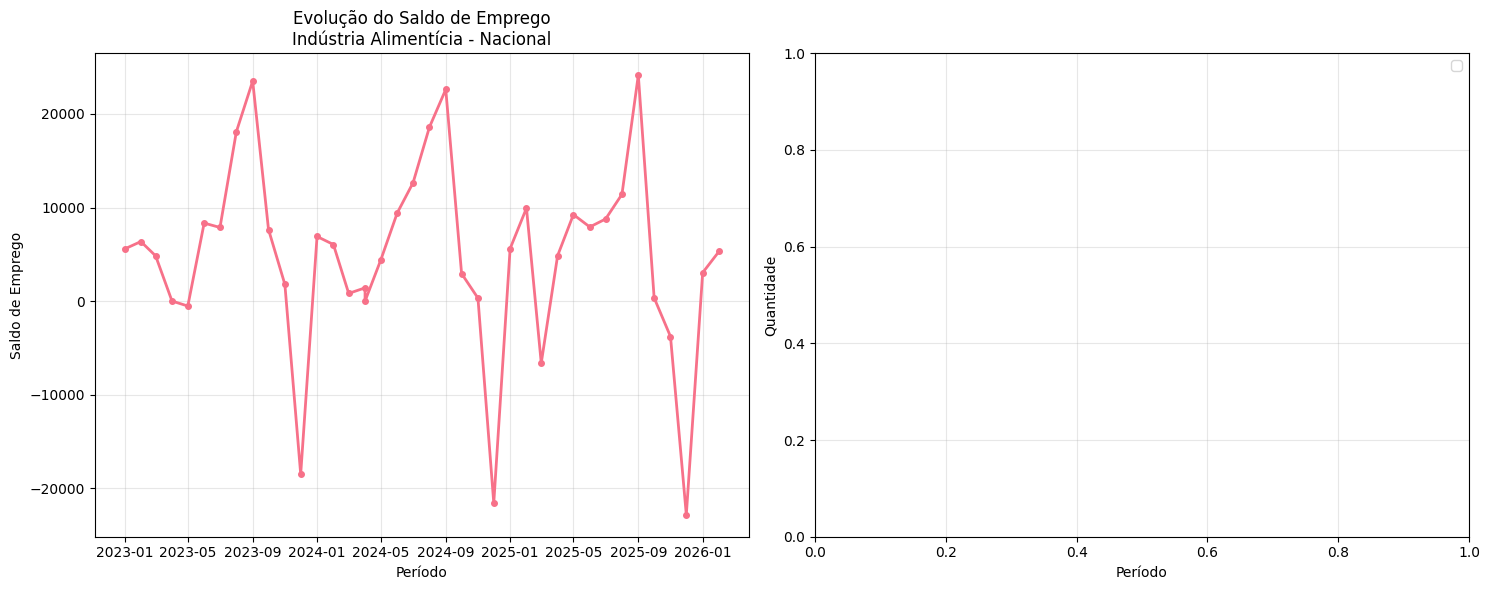

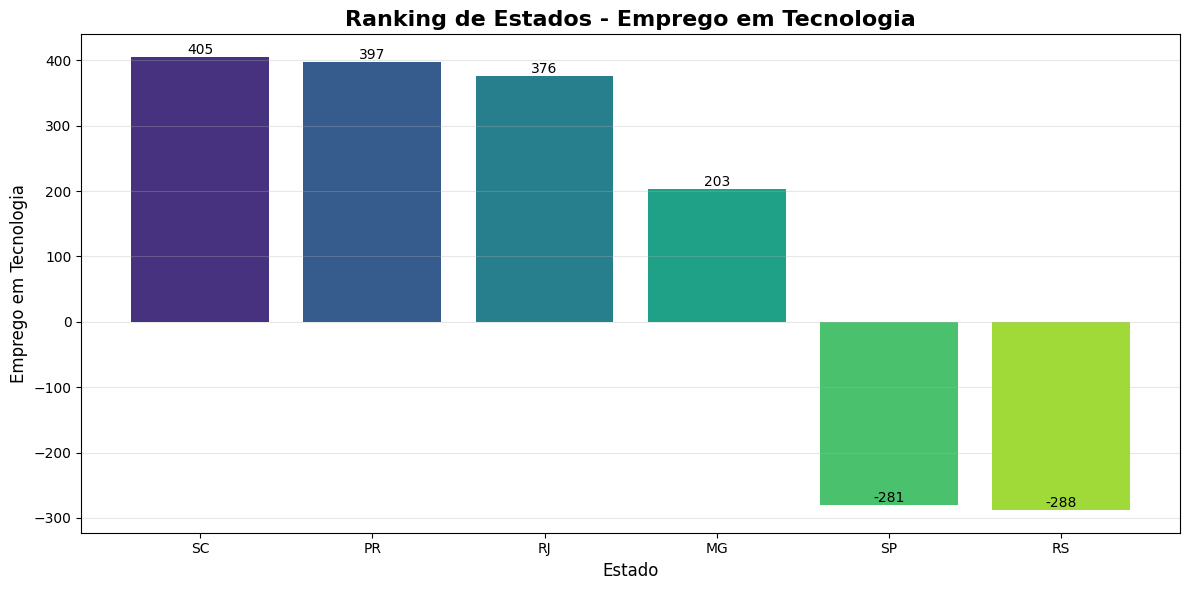

✅ Visualizações geradas com sucesso!


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
# Exemplo 13: Visualização dos dados obtidos
print("📊 Visualizações dos Dados")

# Configurar matplotlib para melhor aparência
plt.style.use('default')
sns.set_palette("husl")

# Gráfico 1: Evolução temporal nacional
if not dados_alimentos.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Saldo de emprego ao longo do tempo
    dados_alimentos['mes_referencia_dt'] = pd.to_datetime(dados_alimentos['mes_referencia'])
    ax1.plot(dados_alimentos['mes_referencia_dt'], dados_alimentos['saldo_reajustado'], 
             marker='o', linewidth=2, markersize=4)
    ax1.set_title('Evolução do Saldo de Emprego\nIndústria Alimentícia - Nacional')
    ax1.set_xlabel('Período')
    ax1.set_ylabel('Saldo de Emprego')
    ax1.grid(True, alpha=0.3)
    
    # Admissões vs Desligamentos
    ax2.set_xlabel('Período')
    ax2.set_ylabel('Quantidade')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Gráfico 2: Ranking de estados (se disponível)
if 'df_ranking' in locals() and not df_ranking.empty:
    plt.figure(figsize=(12, 6))
    bars = plt.bar(df_ranking['Estado'], df_ranking['Emprego_Tech'], 
                   color=sns.color_palette("viridis", len(df_ranking)))
    
    plt.title('Ranking de Estados - Emprego em Tecnologia', fontsize=16, fontweight='bold')
    plt.xlabel('Estado', fontsize=12)
    plt.ylabel('Emprego em Tecnologia', fontsize=12)
    
    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom')
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print("✅ Visualizações geradas com sucesso!")

## 7. 📝 Resumo e Conclusões

In [35]:
# Exemplo 14: Resumo dos dados processados
print("📋 RESUMO DA DEMONSTRAÇÃO")
print("=" * 50)

resumo_execucao = {
    'Funcionalidades Testadas': [
        '✅ Dados Nacionais (divisão, grupo, agrupados)',
        '✅ Dados Estaduais (múltiplos estados)',
        '✅ Dados Municipais (São Paulo capital)',
        '✅ Função criar_indice (análise temporal)',
        '✅ Agrupamentos por setor',
        '✅ Rankings regionais',
        '✅ Visualizações dos dados'
    ],
    
    'Níveis CNAE Testados': [
        '📊 Divisão (nível 2): Indústria Alimentícia (10)',
        '📊 Grupo (nível 3): Frigoríficos (101)',
        '📊 Agrupamentos: Indústria, Serviços, Tecnologia'
    ],
    
    'Geografias Testadas': [
        '🇧🇷 Nacional: Todos os setores',
        '🏛️ Estadual: SP, RJ, MG, RS, PR, SC',
        '🏙️ Municipal: São Paulo Capital'
    ]
}

for categoria, itens in resumo_execucao.items():
    print(f"\n{categoria}:")
    for item in itens:
        print(f"  {item}")

print("\n" + "=" * 50)
print("🎯 PRÓXIMOS PASSOS SUGERIDOS:")
print("1. 📈 Analisar tendências de longo prazo com dados históricos")
print("2. 🗺️ Expandir análise para mais municípios")
print("3. 📊 Criar dashboards interativos com os dados")
print("4. 🔍 Investigar setores específicos em detalhes")
print("5. 📱 Automatizar coleta e análise periódica")

print("\n🚀 Biblioteca SDIC operacional e funcional!")
print("📚 Para mais informações, consulte o README.md")

📋 RESUMO DA DEMONSTRAÇÃO

Funcionalidades Testadas:
  ✅ Dados Nacionais (divisão, grupo, agrupados)
  ✅ Dados Estaduais (múltiplos estados)
  ✅ Dados Municipais (São Paulo capital)
  ✅ Função criar_indice (análise temporal)
  ✅ Agrupamentos por setor
  ✅ Rankings regionais
  ✅ Visualizações dos dados

Níveis CNAE Testados:
  📊 Divisão (nível 2): Indústria Alimentícia (10)
  📊 Grupo (nível 3): Frigoríficos (101)
  📊 Agrupamentos: Indústria, Serviços, Tecnologia

Geografias Testadas:
  🇧🇷 Nacional: Todos os setores
  🏛️ Estadual: SP, RJ, MG, RS, PR, SC
  🏙️ Municipal: São Paulo Capital

🎯 PRÓXIMOS PASSOS SUGERIDOS:
1. 📈 Analisar tendências de longo prazo com dados históricos
2. 🗺️ Expandir análise para mais municípios
3. 📊 Criar dashboards interativos com os dados
4. 🔍 Investigar setores específicos em detalhes
5. 📱 Automatizar coleta e análise periódica

🚀 Biblioteca SDIC operacional e funcional!
📚 Para mais informações, consulte o README.md


## 🚨 Encontrou Problemas?

### Erros Comuns e Soluções:

**ModuleNotFoundError:**
```bash
# Solução 1: Instalar biblioteca
cd python
pip install -e .

# Solução 2: Verificar ambiente Python
python --version
which python
```

**Erro de Conectividade:**
- Verifique sua conexão com a internet
- API pode estar temporariamente indisponível
- Execute novamente após alguns minutos

**Dados Vazios:**
- Período solicitado pode não ter dados
- Códigos CNAE podem estar incorretos
- Tente com datas mais recentes

### Para Suporte:
- 📧 sdic.dados@mdic.gov.br
- 📚 Consulte README.md do projeto
- 🔧 Execute testes: `python testes_consolidados.py`


## 🧪 Verificação das Funções de Estoque


In [3]:

# Testar funções de estoque
print("🧪 Testando funções de estoque...")
print("=" * 50)

try:
    # Teste 1: Estoque Nacional - nível divisão
    print("📊 Teste 1: get_estoque_emprego_nacional (nivel_cnae=2)")
    dados_estoque_nacional = get_estoque_emprego_nacional(nivel_cnae=2)
    
    if not dados_estoque_nacional.empty:
        print(f"✅ Sucesso: {len(dados_estoque_nacional)} registros obtidos")
        print(f"📅 Anos disponíveis: {sorted(dados_estoque_nacional['ano'].astype(int).unique())}")
        print(f"📊 Colunas: {list(dados_estoque_nacional.columns)}")
        display(dados_estoque_nacional.head())
    else:
        print("❌ DataFrame vazio")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")

print("\n" + "-" * 40)

try:
    # Teste 2: Estoque Estadual - SP
    print("📊 Teste 2: get_estoque_emprego_estadual (SP, nivel_cnae=2)")
    dados_estoque_estadual = get_estoque_emprego_estadual(uf='SP', nivel_cnae=2)
    
    if not dados_estoque_estadual.empty:
        print(f"✅ Sucesso: {len(dados_estoque_estadual)} registros obtidos")
        print(f"📅 Anos disponíveis: {sorted(dados_estoque_estadual['ano'].astype(int).unique())}")
        print(f"📊 Colunas: {list(dados_estoque_estadual.columns)}")
        display(dados_estoque_estadual.head())
    else:
        print("❌ DataFrame vazio")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")

print("\n" + "=" * 50)
print("🏁 Teste de funções de estoque concluído!")


🧪 Testando funções de estoque...
📊 Teste 1: get_estoque_emprego_nacional (nivel_cnae=2)
✅ Sucesso: 1000 registros obtidos
📅 Anos disponíveis: [np.int64(2024)]
📊 Colunas: ['sigla_uf', 'ano', 'divisao_cnae_cod', 'divisao_cnae_desc', 'estoque_trabalhadores']


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,AC,2024,01,None,4046
1,AC,2024,02,None,52
2,AC,2024,03,None,20
3,AC,2024,07,None,1
4,AC,2024,08,None,54



----------------------------------------
📊 Teste 2: get_estoque_emprego_estadual (SP, nivel_cnae=2)
✅ Sucesso: 522 registros obtidos
📅 Anos disponíveis: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
📊 Colunas: ['sigla_uf', 'ano', 'divisao_cnae_cod', 'divisao_cnae_desc', 'estoque_trabalhadores']


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,SP,2024,01,None,310850
1,SP,2024,02,None,26396
2,SP,2024,03,None,1684
3,SP,2024,05,None,6
4,SP,2024,06,None,79



🏁 Teste de funções de estoque concluído!


In [4]:

# Testar filtros de CNAE e ano
print("🔍 Testando filtros de CNAE e ano...")
print("=" * 50)

try:
    # Teste com filtro de CNAE específico
    print("📊 Teste 3: get_estoque_emprego_nacional com codigos_cnae=['10']")
    dados_cnae_10 = get_estoque_emprego_nacional(codigos_cnae=['10'], nivel_cnae=2)
    
    if not dados_cnae_10.empty:
        print(f"✅ Sucesso: {len(dados_cnae_10)} registros obtidos")
        print(f"📅 Anos disponíveis: {sorted(dados_cnae_10['ano'].astype(int).unique())}")
        display(dados_cnae_10.tail())
    else:
        print("❌ DataFrame vazio")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")

print("\n" + "-" * 40)

try:
    # Teste com filtro manual de ano
    print("📊 Teste 4: get_estoque_emprego_nacional filtrado para ano >= 2022")
    df_all = get_estoque_emprego_nacional(nivel_cnae=2)
    dados_filtrado = df_all[df_all['ano'].astype(int) >= 2022] if not df_all.empty else df_all
    
    if not dados_filtrado.empty:
        print(f"✅ Sucesso: {len(dados_filtrado)} registros obtidos")
        print(f"📅 Anos: {sorted(dados_filtrado['ano'].astype(int).unique())}")
        display(dados_filtrado.tail())
    else:
        print("❌ DataFrame vazio mesmo sem filtros")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")

print("\n" + "=" * 50)
print("🔍 Investigação concluída!")


🔍 Testando filtros de CNAE e ano...
📊 Teste 3: get_estoque_emprego_nacional com codigos_cnae=['10']
✅ Sucesso: 164 registros obtidos
📅 Anos disponíveis: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
159,RS,2019,10,None,130092
160,SC,2019,10,None,125424
161,SE,2019,10,None,9486
162,SP,2019,10,None,368062
163,TO,2019,10,None,7860



----------------------------------------
📊 Teste 4: get_estoque_emprego_nacional filtrado para ano >= 2022
✅ Sucesso: 1000 registros obtidos
📅 Anos: [np.int64(2024)]


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
995,MS,2024,09,None,117
996,MS,2024,10,None,59122
997,MS,2024,11,None,1450
998,MS,2024,12,None,25
999,MS,2024,13,None,2111



🔍 Investigação concluída!


In [5]:

# Verificar estrutura dos dados de estoque
print("🔍 Explorando estrutura dos dados de estoque...")
print("=" * 50)

try:
    print("📊 Estoque Nacional - Estrutura dos dados:")
    dados_nac = get_estoque_emprego_nacional(nivel_cnae=2, agregado=True)
    
    print(f"📋 Shape: {dados_nac.shape}")
    print(f"📋 Colunas: {list(dados_nac.columns)}")
    print(f"📋 Tipos: {dados_nac.dtypes.to_dict()}")
    print("\n📋 Primeiros registros:")
    display(dados_nac.head())
    
except Exception as e:
    print(f"❌ Erro: {str(e)}")

print("\n" + "-" * 40)

try:
    print("📊 Estoque Estadual SP - Estrutura dos dados:")
    dados_est = get_estoque_emprego_estadual(uf='SP', nivel_cnae=2)
    
    print(f"📋 Shape: {dados_est.shape}")
    print(f"📋 Colunas: {list(dados_est.columns)}")
    print(f"📋 Tipos: {dados_est.dtypes.to_dict()}")
    print("\n📋 Primeiros registros:")
    display(dados_est.head())
    
except Exception as e:
    print(f"❌ Erro: {str(e)}")

print("\n" + "=" * 50)
print("✅ Exploração concluída!")


🔍 Explorando estrutura dos dados de estoque...
📊 Estoque Nacional - Estrutura dos dados:
📋 Shape: (522, 4)
📋 Colunas: ['ano', 'divisao_cnae_cod', 'divisao_cnae_desc', 'estoque_trabalhadores']
📋 Tipos: {'ano': dtype('int64'), 'divisao_cnae_cod': <StringDtype(storage='python', na_value=nan)>, 'divisao_cnae_desc': dtype('O'), 'estoque_trabalhadores': dtype('int64')}

📋 Primeiros registros:


,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,2024,01,None,1639647
1,2024,02,None,142027
2,2024,03,None,21518
3,2024,05,None,3355
4,2024,06,None,24592



----------------------------------------
📊 Estoque Estadual SP - Estrutura dos dados:
📋 Shape: (522, 5)
📋 Colunas: ['sigla_uf', 'ano', 'divisao_cnae_cod', 'divisao_cnae_desc', 'estoque_trabalhadores']
📋 Tipos: {'sigla_uf': <StringDtype(storage='python', na_value=nan)>, 'ano': dtype('int64'), 'divisao_cnae_cod': <StringDtype(storage='python', na_value=nan)>, 'divisao_cnae_desc': dtype('O'), 'estoque_trabalhadores': dtype('int64')}

📋 Primeiros registros:


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,SP,2024,01,None,310850
1,SP,2024,02,None,26396
2,SP,2024,03,None,1684
3,SP,2024,05,None,6
4,SP,2024,06,None,79



✅ Exploração concluída!


In [6]:

# Testar diferentes combinações de parâmetros
print("🧪 Testando diferentes parâmetros...")
print("=" * 50)

# Teste A: nivel_cnae=2 (divisão)
try:
    print("📊 Teste A: nivel_cnae=2 (divisão)")
    dados_a = get_estoque_emprego_nacional(nivel_cnae=2)
    print(f"   Resultado: {len(dados_a)} registros")
    if not dados_a.empty:
        print(f"   Anos: {sorted(dados_a['ano'].astype(int).unique())}")
except Exception as e:
    print(f"   ❌ Erro: {e}")

# Teste B: nivel_cnae=3 (grupo)
try:
    print("\n📊 Teste B: nivel_cnae=3 (grupo)")
    dados_b = get_estoque_emprego_nacional(nivel_cnae=3)
    print(f"   Resultado: {len(dados_b)} registros")
    if not dados_b.empty:
        print(f"   Anos: {sorted(dados_b['ano'].astype(int).unique())}")
except Exception as e:
    print(f"   ❌ Erro: {e}")

# Teste C: com lista de CNAEs
try:
    print("\n📊 Teste C: codigos_cnae=['10', '26', '62']")
    dados_c = get_estoque_emprego_nacional(codigos_cnae=['10', '26', '62'], nivel_cnae=2)
    print(f"   Resultado: {len(dados_c)} registros")
    if not dados_c.empty:
        print(f"   Anos: {sorted(dados_c['ano'].astype(int).unique())}")
except Exception as e:
    print(f"   ❌ Erro: {e}")

# Teste D: agregado=True (soma todos os estados)
try:
    print("\n📊 Teste D: agregado=True")
    dados_d = get_estoque_emprego_nacional(nivel_cnae=2, agregado=True)
    print(f"   Resultado: {len(dados_d)} registros")
    if not dados_d.empty:
        print(f"   Anos: {sorted(dados_d['ano'].astype(int).unique())}")
except Exception as e:
    print(f"   ❌ Erro: {e}")

print("\n" + "=" * 50)
print("🔍 Análise de parâmetros concluída!")


🧪 Testando diferentes parâmetros...
📊 Teste A: nivel_cnae=2 (divisão)
   Resultado: 1000 registros
   Anos: [np.int64(2024)]

📊 Teste B: nivel_cnae=3 (grupo)
   Resultado: 1000 registros
   Anos: [np.int64(2024)]

📊 Teste C: codigos_cnae=['10', '26', '62']
   Resultado: 468 registros
   Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

📊 Teste D: agregado=True
   Resultado: 522 registros
   Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

🔍 Análise de parâmetros concluída!


In [7]:

# Testar estoque com múltiplos estados
print("🧪 Testando estoque estadual com múltiplos estados...")
print("=" * 50)

try:
    print("📊 Teste: get_estoque_emprego_estadual com lista de UFs")
    dados_multi_uf = get_estoque_emprego_estadual(uf=['SP', 'RJ', 'MG'], nivel_cnae=2)
    print(f"   Resultado: {len(dados_multi_uf)} registros")
    if not dados_multi_uf.empty:
        print(f"   Anos: {sorted(dados_multi_uf['ano'].astype(int).unique())}")
        print("\n📋 Primeiros registros:")
        display(dados_multi_uf.head())
except Exception as e:
    print(f"   ❌ Erro: {e}")

print("\n" + "-" * 40)

try:
    print("\n📊 Teste: get_estoque_emprego_estadual com CNAE específico")
    dados_sp_cnae = get_estoque_emprego_estadual(uf='SP', codigos_cnae=['10', '62'], nivel_cnae=2)
    print(f"   Resultado: {len(dados_sp_cnae)} registros")
    if not dados_sp_cnae.empty:
        print(f"   Anos: {sorted(dados_sp_cnae['ano'].astype(int).unique())}")
        display(dados_sp_cnae.head())
except Exception as e:
    print(f"   ❌ Erro: {e}")

print("\n" + "=" * 50)
print("🏁 Teste concluído!")


🧪 Testando estoque estadual com múltiplos estados...
📊 Teste: get_estoque_emprego_estadual com lista de UFs
   Resultado: 1000 registros
   Anos: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

📋 Primeiros registros:


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,MG,2024,01,None,265993
1,MG,2024,02,None,33987
2,MG,2024,03,None,1185
3,MG,2024,05,None,44
4,MG,2024,06,None,4



----------------------------------------

📊 Teste: get_estoque_emprego_estadual com CNAE específico
   Resultado: 12 registros
   Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores
0,SP,2024,10,None,455970
1,SP,2024,62,None,250763
2,SP,2023,10,None,440964
3,SP,2023,62,None,245688
4,SP,2022,10,None,422514



🏁 Teste concluído!



## ✅ Resumo das Funções de Estoque Disponíveis

### 🎯 Funções de Estoque:

| Função | Descrição |
|---|---|
| `get_estoque_emprego_nacional` | Estoque nacional com filtro por CNAE |
| `get_estoque_emprego_estadual` | Estoque por UF com filtro por CNAE |
| `Emprego().get_estoque_emprego_nacional_lista_cnae` | Estoque nacional para lista de CNAEs (POST) |
| `Emprego().get_estoque_emprego_nacional_grupos_cnae` | Estoque nacional agrupando CNAEs (POST) |
| `Emprego().get_estoque_emprego_estadual_lista_cnae` | Estoque estadual para lista de CNAEs (POST) |
| `Emprego().get_estoque_emprego_estadual_grupos_cnae` | Estoque estadual agrupando CNAEs (POST) |

### 📌 Parâmetros Principais:

**`get_estoque_emprego_nacional`**
```python
get_estoque_emprego_nacional(
    codigos_cnae=['10', '26'],  # lista de códigos (opcional)
    nivel_cnae=2,               # 2=divisão, 3=grupo
    agregado=False              # True=soma todos os estados
)
```

**`get_estoque_emprego_estadual`**
```python
get_estoque_emprego_estadual(
    uf='SP',                    # sigla ou lista ['SP', 'RJ']
    codigos_cnae=['10'],        # lista de códigos (opcional)
    nivel_cnae=2                # 2=divisão, 3=grupo
)
```

### 🔧 Filtro por Ano (manual):
```python
df = get_estoque_emprego_nacional(nivel_cnae=2)
df_filtrado = df[df['ano'].astype(int) >= 2022]
```



## 🧪 Verificação das Funções de Estoque Estimado

O estoque estimado combina dados reais de estoque com projeções baseadas no saldo CAGED acumulado a partir do último ano disponível.


In [40]:

# 🔄 Recarregar módulo após alterações no código-fonte
import importlib
import sdic_libraries.dados.emprego as _mod_emprego

importlib.reload(_mod_emprego)

from sdic_libraries.dados.emprego import (
    get_estoque_emprego_estimado_nacional_anual,
    get_estoque_emprego_estimado_estadual_anual,
    get_estoque_emprego_estimado_nacional_anual_agrupado,
    get_estoque_emprego_estimado_estadual_anual_agrupado,
)

print("✅ Módulo recarregado e funções de estoque estimado reimportadas!")


✅ Módulo recarregado e funções de estoque estimado reimportadas!


In [41]:

# Teste 1: Estoque estimado nacional anual - nível divisão
print("🧪 Testando funções de estoque estimado...")
print("=" * 50)

try:
    print("📊 Teste 1: get_estoque_emprego_estimado_nacional_anual (nivel_cnae='divisao', codigo_cnae='10')")
    dados_est_nac = get_estoque_emprego_estimado_nacional_anual(
        nivel_cnae='divisao',
        codigo_cnae='10',
        ano_minimo=2019,
        ano_maximo=2025
    )
    
    if not dados_est_nac.empty:
        print(f"✅ Sucesso: {len(dados_est_nac)} registros obtidos")
        print(f"📅 Anos disponíveis: {sorted(dados_est_nac['ano'].astype(int).unique())}")
        print(f"📋 Colunas: {list(dados_est_nac.columns)}")
        if 'origem' in dados_est_nac.columns:
            print(f"🔍 Origens: {dados_est_nac['origem'].value_counts().to_dict()}")
        display(dados_est_nac)
    else:
        print("❌ DataFrame vazio")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")


🧪 Testando funções de estoque estimado...
📊 Teste 1: get_estoque_emprego_estimado_nacional_anual (nivel_cnae='divisao', codigo_cnae='10')
✅ Sucesso: 7 registros obtidos
📅 Anos disponíveis: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
📋 Colunas: ['ano', 'divisao_cnae_cod', 'divisao_cnae_desc', 'estoque_trabalhadores', 'origem', 'saldo_reajustado']
🔍 Origens: {'Real': 6, 'Estimação': 1}


,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores,origem,saldo_reajustado
0,2019,10,Fabricação De Produtos Alimentícios,1577662.0,Real,NaN
1,2020,10,Fabricação De Produtos Alimentícios,1634511.0,Real,NaN
2,2021,10,Fabricação De Produtos Alimentícios,1670372.0,Real,NaN
3,2022,10,Fabricação De Produtos Alimentícios,1805840.0,Real,NaN
4,2023,10,Fabricação De Produtos Alimentícios,1856188.0,Real,NaN
5,2024,10,Fabricação De Produtos Alimentícios,1931701.0,Real,NaN
6,2025,10,Fabricação De Produtos Alimentícios,1980714.0,Estimação,49013.0


In [22]:
dados_est_nac.tail()

,sigla_uf,ano,divisao_cnae_cod,divisao_cnae_desc,estoque_trabalhadores,origem
159,RS,1970,10,None,130092,Real
160,SC,1970,10,None,125424,Real
161,SE,1970,10,None,9486,Real
162,SP,1970,10,None,368062,Real
163,TO,1970,10,None,7860,Real


In [ ]:

# Teste 2: Estoque estimado estadual anual - SP, nível divisão
print("📊 Teste 2: get_estoque_emprego_estimado_estadual_anual (SP, 'divisao', '10')")

try:
    dados_est_sp = get_estoque_emprego_estimado_estadual_anual(
        sigla_uf='SP',
        nivel_cnae='divisao',
        codigo_cnae='10',
        ano_minimo=2018,
        ano_maximo=2026
    )
    
    if not dados_est_sp.empty:
        print(f"✅ Sucesso: {len(dados_est_sp)} registros obtidos")
        print(f"📅 Anos disponíveis: {sorted(dados_est_sp['ano'].astype(int).unique())}")
        print(f"📋 Colunas: {list(dados_est_sp.columns)}")
        if 'origem' in dados_est_sp.columns:
            print(f"🔍 Origens: {dados_est_sp['origem'].value_counts().to_dict()}")
        display(dados_est_sp)
    else:
        print("❌ DataFrame vazio")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")


In [ ]:

# Teste 3: Estoque estimado nacional agrupado
print("📊 Teste 3: get_estoque_emprego_estimado_nacional_anual_agrupado")

try:
    dados_est_grupo_nac = get_estoque_emprego_estimado_nacional_anual_agrupado(
        nome_grupo="Indústria Alimentícia e Frigoríficos",
        lista_cnae=['10', '101'],
        ano_minimo=2018,
        ano_maximo=2026
    )
    
    if not dados_est_grupo_nac.empty:
        print(f"✅ Sucesso: {len(dados_est_grupo_nac)} registros obtidos")
        print(f"📅 Anos disponíveis: {sorted(dados_est_grupo_nac['ano'].astype(int).unique())}")
        print(f"📋 Colunas: {list(dados_est_grupo_nac.columns)}")
        if 'origem' in dados_est_grupo_nac.columns:
            print(f"🔍 Origens: {dados_est_grupo_nac['origem'].value_counts().to_dict()}")
        display(dados_est_grupo_nac)
    else:
        print("❌ DataFrame vazio")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")


In [ ]:

# Teste 4: Estoque estimado estadual agrupado - SP
print("📊 Teste 4: get_estoque_emprego_estimado_estadual_anual_agrupado (SP)")

try:
    dados_est_grupo_sp = get_estoque_emprego_estimado_estadual_anual_agrupado(
        sigla_uf='SP',
        nome_grupo="Indústria Alimentícia e Frigoríficos",
        lista_cnae=['10', '101'],
        ano_minimo=2018,
        ano_maximo=2026
    )
    
    if not dados_est_grupo_sp.empty:
        print(f"✅ Sucesso: {len(dados_est_grupo_sp)} registros obtidos")
        print(f"📅 Anos disponíveis: {sorted(dados_est_grupo_sp['ano'].astype(int).unique())}")
        print(f"📋 Colunas: {list(dados_est_grupo_sp.columns)}")
        if 'origem' in dados_est_grupo_sp.columns:
            print(f"🔍 Origens: {dados_est_grupo_sp['origem'].value_counts().to_dict()}")
        display(dados_est_grupo_sp)
    else:
        print("❌ DataFrame vazio")
        
except Exception as e:
    print(f"❌ Erro: {str(e)}")

print("\n" + "=" * 50)
print("🏁 Testes de estoque estimado concluídos!")
print("ℹ️  Nota: Estoque estimado municipal não implementado (NotImplementedError).")
